# **Start**

In [1]:
# ===================== FULL CELL: CENTER-PIXEL SLIDING WINDOW PREDICTION =====================

# --- STEP 1: SETUP ---
!pip install -q rasterio tensorflow scikit-learn

import rasterio
import numpy as np
import tensorflow as tf
import joblib
import time

# --- STEP 2: PATHS ---
full_image_path = "/kaggle/input/true-image-updated/Singrauli_Merged_Image.tif"
model_path = "/kaggle/input/lulc-15/tensorflow1/default/1/cnn_lulc_model_final_15.keras"
scaler_path = "/kaggle/input/lulc-15/tensorflow1/default/1/cnn_scaler_15.joblib"
output_map_path = "/kaggle/working/Singrauli_CNN_CENTER_PIXEL.tif"

# --- SLIDING WINDOW CONFIG ---
STRIDE = 1                  # MUST be 1 for true center-pixel labeling
PRED_BATCH_SIZE = 8192       # Reduce if you get OOM errors

# --- STEP 3: LOAD MODEL & SCALER ---
print("Loading model and scaler...")
model = tf.keras.models.load_model(model_path)
scaler = joblib.load(scaler_path)

_, PATCH_SIZE, _, BANDS = model.input_shape
HALF = PATCH_SIZE // 2

print(f"Model expects {PATCH_SIZE}×{PATCH_SIZE} patches with {BANDS} bands")

# --- STEP 4: LOAD IMAGE & PAD ---
print("Loading and padding image...")
with rasterio.open(full_image_path) as src:
    image = src.read()                     # (bands, H, W)
    meta = src.meta.copy()
    H, W = src.height, src.width

# Zero padding for edge handling
padded = np.pad(
    image,
    ((0, 0), (HALF, HALF), (HALF, HALF)),
    mode="constant",
    constant_values=0
)

# Output classification map
prediction_map = np.full((H, W), 255, dtype=np.uint8)

# --- STEP 5: SLIDING WINDOW CENTER-PIXEL PREDICTION ---
print("Starting sliding-window prediction...")
start_time = time.time()

patches = []
coords = []

total_pixels = H * W
processed_pixels = 0
report_every = 10_000   # progress update frequency

print(f"Total pixels to classify: {total_pixels:,}")

for row in range(H):
    for col in range(W):
        patch = padded[:, row:row+PATCH_SIZE, col:col+PATCH_SIZE]
        patches.append(patch)
        coords.append((row, col))

        if len(patches) == PRED_BATCH_SIZE:
            batch = np.array(patches)                 # (B, bands, H, W)
            batch = np.moveaxis(batch, 1, -1)         # (B, H, W, bands)

            flat = batch.reshape(-1, BANDS)
            flat = np.nan_to_num(flat)
            flat = scaler.transform(flat)
            batch = flat.reshape(-1, PATCH_SIZE, PATCH_SIZE, BANDS)

            preds = model.predict(batch, verbose=0)
            classes = np.argmax(preds, axis=1)

            for (r, c), cls in zip(coords, classes):
                prediction_map[r, c] = cls

            processed_pixels += len(patches)

            # ---- PROGRESS REPORT ----
            if processed_pixels % report_every == 0:
                percent = (processed_pixels / total_pixels) * 100
                elapsed = time.time() - start_time
                print(f"Processed {processed_pixels:,}/{total_pixels:,} "
                      f"({percent:.2f}%) | Elapsed: {elapsed/60:.1f} min")

            patches, coords = [], []

# --- PROCESS REMAINING PATCHES ---
if patches:
    batch = np.array(patches)
    batch = np.moveaxis(batch, 1, -1)

    flat = batch.reshape(-1, BANDS)
    flat = scaler.transform(flat)
    batch = flat.reshape(-1, PATCH_SIZE, PATCH_SIZE, BANDS)

    preds = model.predict(batch, verbose=0)
    classes = np.argmax(preds, axis=1)

    for (r, c), cls in zip(coords, classes):
        prediction_map[r, c] = cls

    processed_pixels += len(patches)

# --- FINAL TIME REPORT ---
total_time = time.time() - start_time
print(f"\n✅ Prediction finished")
print(f"Pixels classified: {processed_pixels:,}")
print(f"Total time: {total_time/60:.2f} minutes")

# --- STEP 6: SAVE OUTPUT GEO-TIFF ---
meta.update({
    "count": 1,
    "dtype": "uint8",
    "nodata": 255,
    "compress": "lzw"
})

with rasterio.open(output_map_path, "w", **meta) as dst:
    dst.write(prediction_map, 1)

print(f"📁 Output saved at:\n{output_map_path}")
# ============================================================================================

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.6/37.6 MB 53.3 MB/s eta 0:00:00:00:0100:01


2026-01-30 10:33:06.303213: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1769769186.507016      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1769769186.573317      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1769769187.038894      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1769769187.038931      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1769769187.038933      55 computation_placer.cc:177] computation placer alr

Loading model and scaler...


I0000 00:00:1769769201.515771      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1769769201.518354      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model expects 15×15 patches with 11 bands
Loading and padding image...
Starting sliding-window prediction...
Total pixels to classify: 107,259,168


I0000 00:00:1769769237.925512     110 service.cc:152] XLA service 0x78fa80003b60 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1769769237.925546     110 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1769769237.925550     110 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1769769238.068223     110 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1769769239.312352     110 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


Processed 5,120,000/107,259,168 (4.77%) | Elapsed: 9.2 min
Processed 10,240,000/107,259,168 (9.55%) | Elapsed: 18.3 min
Processed 15,360,000/107,259,168 (14.32%) | Elapsed: 27.5 min
Processed 20,480,000/107,259,168 (19.09%) | Elapsed: 36.6 min
Processed 25,600,000/107,259,168 (23.87%) | Elapsed: 45.8 min
Processed 30,720,000/107,259,168 (28.64%) | Elapsed: 55.1 min
Processed 35,840,000/107,259,168 (33.41%) | Elapsed: 64.2 min
Processed 40,960,000/107,259,168 (38.19%) | Elapsed: 73.5 min
Processed 46,080,000/107,259,168 (42.96%) | Elapsed: 82.6 min
Processed 51,200,000/107,259,168 (47.73%) | Elapsed: 91.7 min
Processed 56,320,000/107,259,168 (52.51%) | Elapsed: 100.8 min
Processed 61,440,000/107,259,168 (57.28%) | Elapsed: 109.9 min
Processed 66,560,000/107,259,168 (62.06%) | Elapsed: 119.1 min
Processed 71,680,000/107,259,168 (66.83%) | Elapsed: 128.2 min
Processed 76,800,000/107,259,168 (71.60%) | Elapsed: 137.2 min
Processed 81,920,000/107,259,168 (76.38%) | Elapsed: 146.2 min
Proces

Displaying classified map from: /kaggle/working/Singrauli_CNN_CENTER_PIXEL.tif


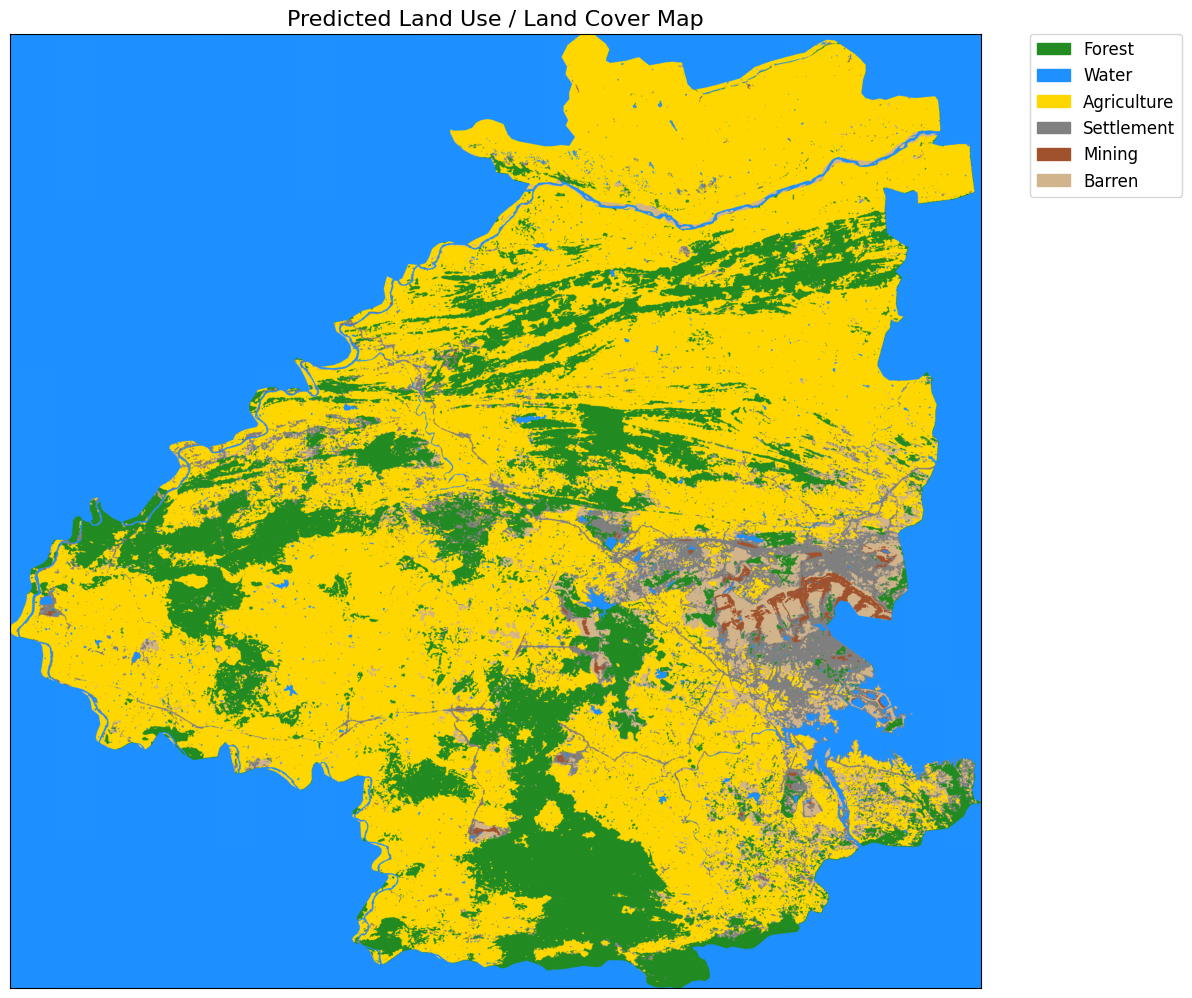

In [3]:
# =====================================================================================
# CNN LULC CLASSIFIED MAP VISUALIZATION
# Handles class range 0–5 OR 1–6 automatically
# Matches GEE color palette exactly
# =====================================================================================

import rasterio
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import matplotlib.patches as mpatches
import numpy as np

# =====================================================================================
# CONFIGURATION
# =====================================================================================

output_map_path = "/kaggle/working/Singrauli_CNN_CENTER_PIXEL.tif"

# --- GEE‑MATCHED CLASS DEFINITIONS ---
# Final standard:
# 1 = Water, 2 = Agriculture, 3 = Settlement, 4 = Mining, 5 = Barren, 6 = Forest

CLASS_NAMES = [
    "Water",
    "Agriculture",
    "Settlement",
    "Mining",
    "Barren / Scrub",
    "Forest"
]

# EXACT SAME PALETTE AS GEE
CLASS_COLORS = [
    "#0000FF",  # Water
    "#E6E600",  # Agriculture
    "#FF0000",  # Settlement
    "#000000",  # Mining
    "#C2B280",  # Barren
    "#006400"   # Forest
]

# =====================================================================================
# VISUALIZATION
# =====================================================================================

print(f"Displaying classified map from: {output_map_path}")

try:
    with rasterio.open(output_map_path) as src:
        classified = src.read(1)
        nodata = src.nodata

    # Mask NoData
    if nodata is not None:
        classified = np.ma.masked_equal(classified, nodata)

    # =================================================================================
    # HANDLE CLASS SCHEME (0–5 or 1–6)
    # =================================================================================

    unique_classes = np.unique(classified.compressed())
    print("Detected class values:", unique_classes)

    # If CNN output is 0–5 → convert to 1–6
    if unique_classes.min() == 0:
        print("Remapping classes from 0–5 → 1–6")
        classified = classified + 1

    # =================================================================================
    # COLORMAP & NORMALIZATION
    # =================================================================================

    cmap = colors.ListedColormap(CLASS_COLORS)

    # Boundaries ensure each integer gets exactly one color
    bounds = np.arange(1, 8) - 0.5  # [0.5 ... 6.5]
    norm = colors.BoundaryNorm(bounds, cmap.N)

    # =================================================================================
    # PLOT
    # =================================================================================

    fig, ax = plt.subplots(figsize=(12, 12))

    im = ax.imshow(classified, cmap=cmap, norm=norm)

    # =================================================================================
    # LEGEND
    # =================================================================================

    legend_patches = [
        mpatches.Patch(color=color, label=name)
        for color, name in zip(CLASS_COLORS, CLASS_NAMES)
    ]

    ax.legend(
        handles=legend_patches,
        bbox_to_anchor=(1.05, 1),
        loc="upper left",
        fontsize=12,
        frameon=True
    )

    # =================================================================================
    # FINAL TOUCHES
    # =================================================================================

    ax.set_title("CNN‑Based Land Use / Land Cover Classification", fontsize=16)
    ax.set_xticks([])
    ax.set_yticks([])

    plt.tight_layout()
    plt.show()

except FileNotFoundError:
    print(f"❌ File not found: {output_map_path}")
except Exception as e:
    print(f"❌ Error: {e}")